# NB02 — Exploratory Data Analysis
## Urdu Code-Switch Emotion Detector

**Purpose:** Analyze the locked train split to understand patterns in text length, language composition, emojis, tokens, and their relationship to emotion labels.

**Input:** `data/processed/train.csv` (from NB01)

**Output:** 8-10 figures in `outputs/figures/` with `eda_` prefix

---
## Section 0 — Setup

### Imports and configuration

In [2]:
# -- Data manipulation --
import pandas as pd
import numpy as np

# -- Visualisation --
import matplotlib.pyplot as plt
import seaborn as sns

# -- Text analytics --
import re
from collections import Counter

# -- Path management --
from pathlib import Path

# -- Reproducibility --
RANDOM_STATE = 42
sns.set_style('whitegrid')

# -- Paths --
PROCESSED_PATH = Path("../data/processed/")
FIGURES_PATH   = Path("../outputs/figures/")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("Libraries loaded OK")

Libraries loaded OK


### Helper functions

In [3]:
def print_section(title: str) -> None:
    """Consistent section header for all checks in this notebook."""
    print(f"{'=' * 60} {title}{'=' * 60}")

def save_figure(fig, filename: str, dpi: int = 150) -> None:
    """Save a figure to outputs/figures/ and confirm with print."""
    path = FIGURES_PATH / filename
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f"Saved -> {path}")

print("Helper functions defined")

Helper functions defined


### Load train split

In [4]:
# CRITICAL: train split only. val.csv / test.csv stay untouched until
# final model evaluation — see NB01 SPEC.md, "Data leakage prevention".
df = pd.read_csv(PROCESSED_PATH / 'train.csv')

print(f"Loaded train.csv: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Loaded train.csv: 13,674 rows, 3 columns
Columns: ['text', 'label', 'text_clean']


---
## Section 1 — Dataset Overview

In [5]:
print_section("SECTION 1 — DATASET OVERVIEW")

print(f"Shape: {df.shape}")
print(f"Dtypes:{df.dtypes}")
print(f"Missing values:{df.isnull().sum()}")
print(f"Duplicate rows (on text_clean): {df.duplicated(subset='text_clean').sum()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

============================================================ SECTION 1 — DATASET OVERVIEW============================================================
Shape: (13674, 3)
Dtypes:text          object
label         object
text_clean    object
dtype: object
Missing values:text          0
label         0
text_clean    0
dtype: int64
Duplicate rows (on text_clean): 0
Memory usage: 4.81 MB


---
## Section 2 — Target Variable Analysis (Univariate)

In [6]:
print_section("SECTION 2 — TARGET VARIABLE ANALYSIS")

counts = df['label'].value_counts()
pct    = df['label'].value_counts(normalize=True) * 100
ratio  = counts.max() / counts.min()

summary = pd.DataFrame({'count': counts, 'pct_of_total': pct.round(1)})
print(summary)
print(f"Imbalance ratio (max/min): {ratio:.1f}x")

============================================================ SECTION 2 — TARGET VARIABLE ANALYSIS============================================================
          count  pct_of_total
label                        
neutral    7959          58.2
happy      2559          18.7
anger      2386          17.4
sad         470           3.4
fear        155           1.1
surprise    145           1.1
Imbalance ratio (max/min): 54.9x


Saved -> ../outputs/figures/eda_class_distribution.png


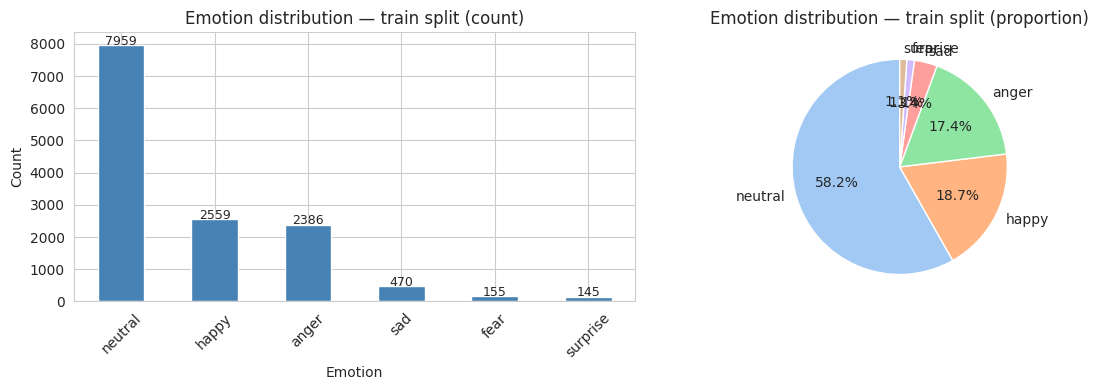

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Emotion distribution — train split (count)')
axes[0].set_xlabel('Emotion'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=9)

counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('pastel'))
axes[1].set_title('Emotion distribution — train split (proportion)')
axes[1].set_ylabel('')

plt.tight_layout()
save_figure(fig, 'eda_class_distribution.png')
plt.show()

---
## Section 3 — Text Length Analysis (Univariate)

In [8]:
print_section("SECTION 3 — TEXT LENGTH ANALYSIS")

df['char_count']  = df['text_clean'].str.len()
df['word_count']  = df['text_clean'].str.split().str.len()
df['token_count'] = df['word_count']  # whitespace tokeniser — see note below

print(df[['char_count', 'word_count', 'token_count']].describe())

p95 = df['token_count'].quantile(0.95)
print(f"95th percentile token count: {p95:.0f}")
print("Compare this against NB03's max_length=128 — it should sit comfortably")
print("above this value (XLM-R's subword tokeniser will produce somewhat")
print("more tokens than this whitespace count, so treat this as a floor).")

============================================================ SECTION 3 — TEXT LENGTH ANALYSIS============================================================
         char_count    word_count   token_count
count  13674.000000  13674.000000  13674.000000
mean     107.787041     21.385476     21.385476
std       73.514973     14.546006     14.546006
min        1.000000      1.000000      1.000000
25%       55.000000     11.000000     11.000000
50%       87.000000     17.000000     17.000000
75%      139.000000     27.000000     27.000000
max     1160.000000    235.000000    235.000000
95th percentile token count: 51
Compare this against NB03's max_length=128 — it should sit comfortably
above this value (XLM-R's subword tokeniser will produce somewhat
more tokens than this whitespace count, so treat this as a floor).


Saved -> ../outputs/figures/eda_text_length_distribution.png


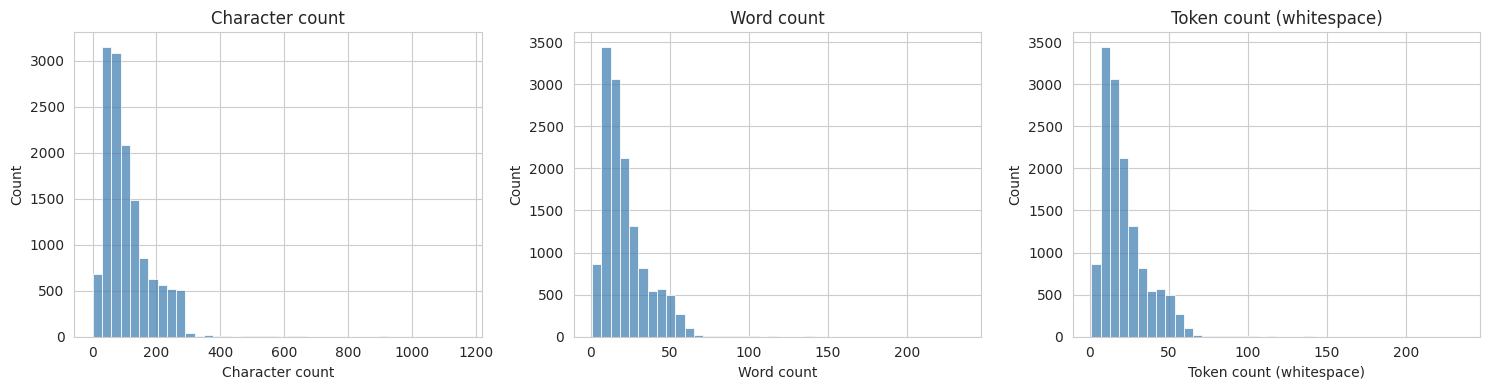

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(
    axes,
    ['char_count', 'word_count', 'token_count'],
    ['Character count', 'Word count', 'Token count (whitespace)']
):
    sns.histplot(df[col], bins=40, ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel(title)

plt.tight_layout()
save_figure(fig, 'eda_text_length_distribution.png')
plt.show()

/tmp/ipykernel_8936/3113701306.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='word_count', ax=ax, palette='Set3')


Saved -> ../outputs/figures/eda_token_length_by_emotion.png


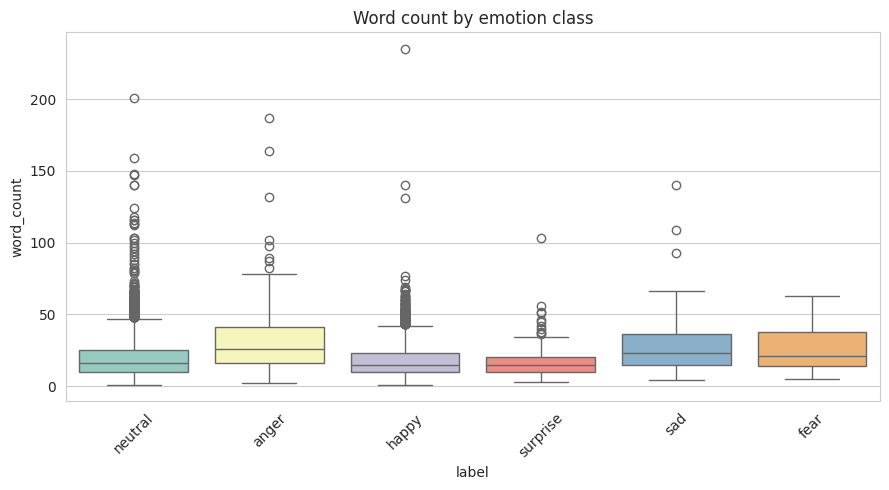

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='label', y='word_count', ax=ax, palette='Set3')
ax.set_title('Word count by emotion class')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_figure(fig, 'eda_token_length_by_emotion.png')
plt.show()

---
## Section 4 — Language Composition Analysis

In [11]:
print_section("SECTION 4 — LANGUAGE COMPOSITION ANALYSIS")

# -- ASCII vs Unicode — proxy for emoji + Urdu-script + symbol density --
def ascii_ratio(text: str) -> float:
    text = str(text)
    if len(text) == 0:
        return 0.0
    ascii_chars = sum(1 for ch in text if ord(ch) < 128)
    return ascii_chars / len(text)

df['ascii_ratio'] = df['text_clean'].apply(ascii_ratio)

# -- English word ratio — dictionary-based, distinguishes English from --
#    Roman Urdu (both are ASCII, so char-level ratio alone can't do this) --
ENGLISH_COMMON_WORDS = {
    'i','you','he','she','it','we','they','am','is','are','was','were','be',
    'been','have','has','had','do','does','did','will','would','can','could',
    'the','a','an','and','or','but','not','no','yes','so','if','because',
    'this','that','these','those','my','your','his','her','its','our','their',
    'to','of','in','on','at','for','with','from','about','like','just',
    'really','very','too','much','good','bad','happy','sad','angry','love',
    'hate','feel','feeling','think','know','want','need','get','got','go',
    'going','went','say','said','tell','told','what','why','how','when',
    'who','which','some','any','all','more','most','than','then','now',
}

def english_word_ratio(text: str) -> float:
    words = re.findall(r"[a-zA-Z']+", str(text).lower())
    if not words:
        return 0.0
    english = sum(1 for w in words if w in ENGLISH_COMMON_WORDS)
    return english / len(words)

df['english_ratio'] = df['text_clean'].apply(english_word_ratio)

print(df[['ascii_ratio', 'english_ratio']].describe())

============================================================ SECTION 4 — LANGUAGE COMPOSITION ANALYSIS============================================================
        ascii_ratio  english_ratio
count  13674.000000   13674.000000
mean       0.999998       0.105379
std        0.000231       0.114114
min        0.972973       0.000000
25%        1.000000       0.000000
50%        1.000000       0.074074
75%        1.000000       0.166667
max        1.000000       0.700000


Saved -> ../outputs/figures/eda_language_composition.png


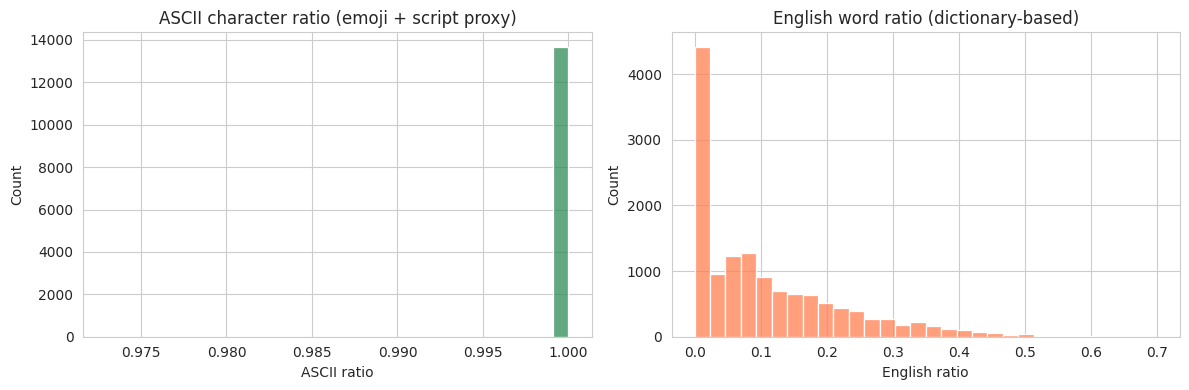

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['ascii_ratio'], bins=30, ax=axes[0], color='seagreen')
axes[0].set_title('ASCII character ratio (emoji + script proxy)')
axes[0].set_xlabel('ASCII ratio')

sns.histplot(df['english_ratio'], bins=30, ax=axes[1], color='coral')
axes[1].set_title('English word ratio (dictionary-based)')
axes[1].set_xlabel('English ratio')

plt.tight_layout()
save_figure(fig, 'eda_language_composition.png')
plt.show()

In [13]:
def classify_mix(ratio: float) -> str:
    if ratio >= 0.8:
        return 'mostly_english'
    elif ratio <= 0.2:
        return 'mostly_roman_urdu'
    else:
        return 'code_mixed'

df['language_mix'] = df['english_ratio'].apply(classify_mix)
print(df['language_mix'].value_counts())
print(f"100% English sentences: {(df['english_ratio'] == 1.0).sum():,}")

language_mix
mostly_roman_urdu    11224
code_mixed            2450
Name: count, dtype: int64
100% English sentences: 0


---
## Section 5 — Emoji Analysis

In [14]:
print_section("SECTION 5 — EMOJI ANALYSIS")

EMOJI_PATTERN = re.compile(
    "["
    "🌀-🗿"
    "😀-🙏"
    "🚀-🛿"
    "🤀-🧿"
    "☀-⛿"
    "✀-➿"
    "]"
)

def extract_emojis(text: str) -> list:
    return EMOJI_PATTERN.findall(str(text))

df['emoji_list']  = df['text_clean'].apply(extract_emojis)
df['emoji_count'] = df['emoji_list'].str.len()

all_emojis = [e for emojis in df['emoji_list'] for e in emojis]
top_emojis = Counter(all_emojis).most_common(15)

print(f"Sentences with >=1 emoji: {(df['emoji_count'] > 0).sum():,} "
      f"({(df['emoji_count'] > 0).mean()*100:.1f}%)")
print("Top 15 emojis overall:")
for emoji, count in top_emojis:
    print(f"  {emoji}  {count}")

============================================================ SECTION 5 — EMOJI ANALYSIS============================================================
Sentences with >=1 emoji: 0 (0.0%)
Top 15 emojis overall:


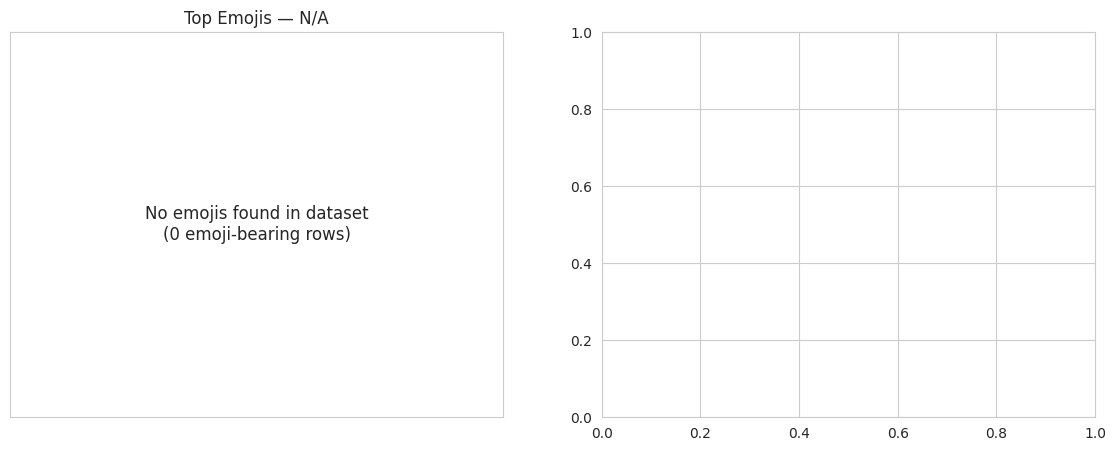

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(top_emojis) > 0:
    emojis, freqs = zip(*top_emojis)
    axes[0].bar(range(len(emojis)), freqs, color='goldenrod')
    axes[0].set_xticks(range(len(emojis)))
    axes[0].set_xticklabels(emojis, fontsize=14)
    axes[0].set_title("Top 15 Emojis by Frequency")
    axes[0].set_ylabel("Count")
else:
    axes[0].text(0.5, 0.5, "No emojis found in dataset\n(0 emoji-bearing rows)",
                 ha='center', va='center', fontsize=12, transform=axes[0].transAxes)
    axes[0].set_title("Top Emojis — N/A")
    axes[0].set_xticks([])
    axes[0].set_yticks([])

# (keep whatever axes[1] code already existed below this, unchanged)

---
## Section 6 — Token Analysis

In [16]:
print_section("SECTION 6 — TOKEN ANALYSIS")

# Used only to ANNOTATE output below — never to filter the dataset.
# Stripping stopwords would help a classic bag-of-words baseline, but the
# XLM-R model in NB03 needs the full sentence, function words included.
STOPWORDS = {
    'the','a','an','is','am','are','was','were','to','of','in','on','at',
    'and','or','but','i','you','it','this','that','my','your',
    'hai','hain','ka','ki','ke','ko','se','main','mein','ho','ye','wo','na',
}

def tokenize(text: str) -> list:
    return str(text).split()  # whitespace tokeniser, per project convention

df['tokens'] = df['text_clean'].apply(tokenize)

all_tokens  = [t.lower() for tokens in df['tokens'] for t in tokens]
top_overall = Counter(all_tokens).most_common(20)

print("Top 20 tokens overall:")
stopword_hits = 0
for tok, count in top_overall:
    is_stop = tok in STOPWORDS
    stopword_hits += is_stop
    print(f"  {tok:<15} {count:>6}{'  (stopword)' if is_stop else ''}")

print(f"{stopword_hits}/20 top tokens are stopwords — "
      f"{'function words dominate' if stopword_hits > 10 else 'content words dominate'} "
      f"the frequency list.")

============================================================ SECTION 6 — TOKEN ANALYSIS============================================================
Top 20 tokens overall:
  hai               6074  (stopword)
  to                3519  (stopword)
  k                 3103
  ki                3090  (stopword)
  ko                2918  (stopword)
  ka                2858  (stopword)
  ho                2405  (stopword)
  se                2198  (stopword)
  is                2121  (stopword)
  bhi               1990
  me                1962
  ke                1839  (stopword)
  ye                1650  (stopword)
  i                 1494  (stopword)
  or                1472  (stopword)
  aur               1458
  nahi              1455
  hi                1410
  bhai              1406
  kya               1357
12/20 top tokens are stopwords — function words dominate the frequency list.


Saved -> ../outputs/figures/eda_top_tokens_per_emotion.png


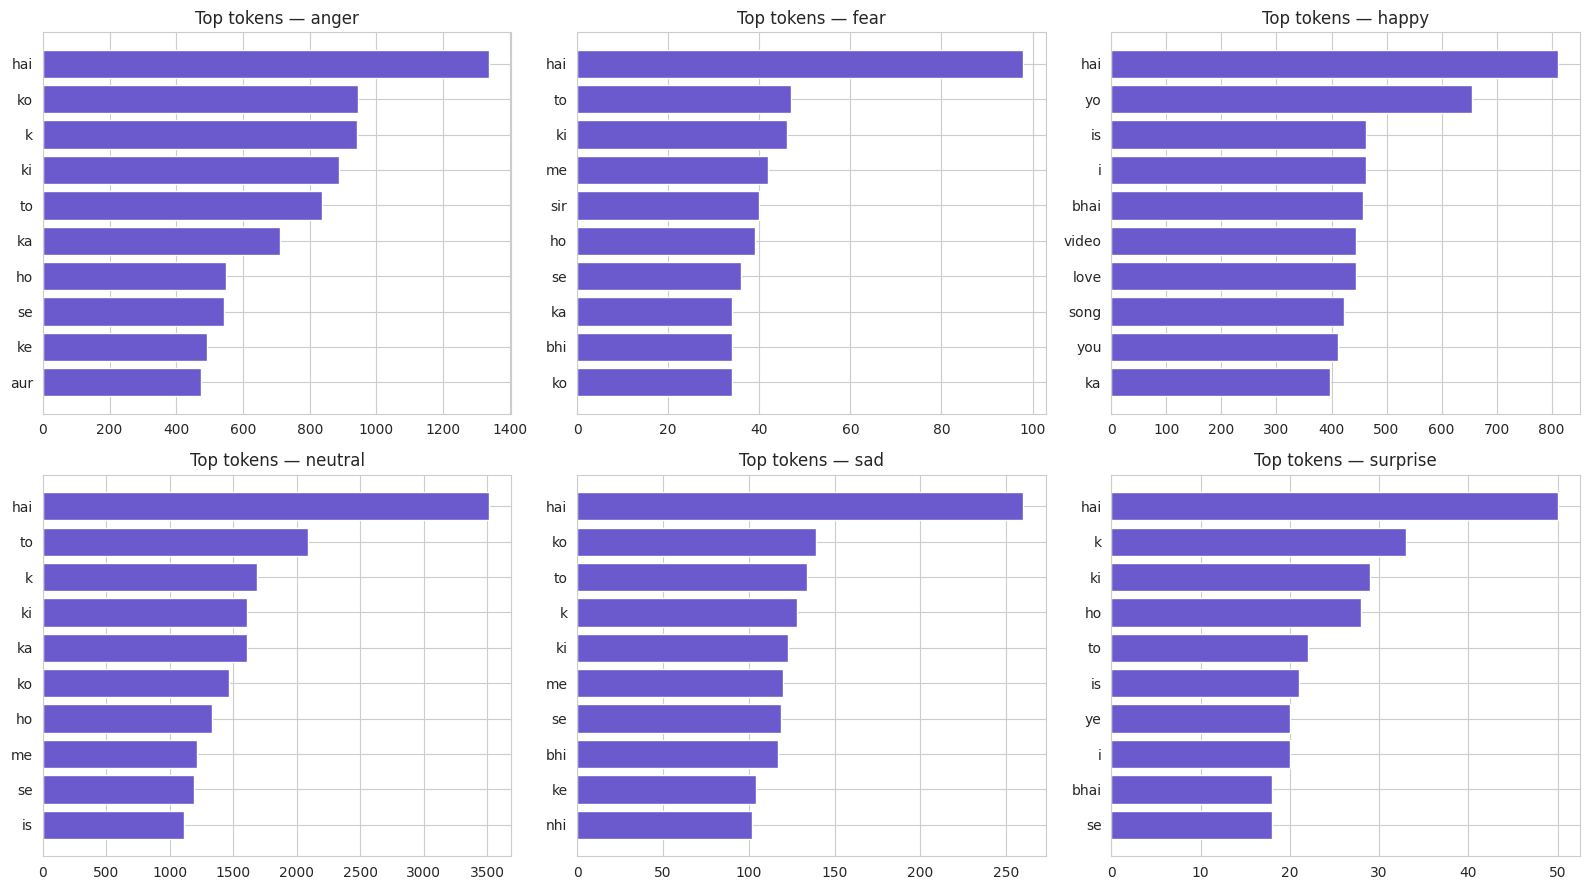

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, label in zip(axes, sorted(df['label'].unique())):
    class_tokens = [t.lower() for tokens in df.loc[df['label'] == label, 'tokens']
                     for t in tokens]
    top_class = Counter(class_tokens).most_common(10)
    if top_class:
        toks, freqs = zip(*top_class)
        ax.barh(toks[::-1], freqs[::-1], color='slateblue')
    ax.set_title(f"Top tokens — {label}")

plt.tight_layout()
save_figure(fig, 'eda_top_tokens_per_emotion.png')
plt.show()

---
## Section 7 — Outlier Analysis

In [18]:
print_section("SECTION 7 — OUTLIER ANALYSIS")

p1, p99 = df['word_count'].quantile([0.01, 0.99])
print(f"Word count — 1st percentile: {p1:.0f}, 99th percentile: {p99:.0f}")

shortest = df.nsmallest(5, 'word_count')[['text_clean', 'word_count', 'label']]
longest  = df.nlargest(5, 'word_count')[['text_clean', 'word_count', 'label']]

print("5 shortest sentences:")
display(shortest)
print("5 longest sentences:")
display(longest)

# Repeated-character emphasis, e.g. "soooo good" — FLAG only, never remove.
# NB01's cleaning rules explicitly preserve this; it's emphasis, not noise.
def has_char_spam(text: str, min_repeat: int = 4) -> bool:
    return bool(re.search(r'(.){' + str(min_repeat - 1) + ',}', str(text)))

df['has_char_spam'] = df['text_clean'].apply(has_char_spam)
print(f"Sentences with repeated-character emphasis: {df['has_char_spam'].sum():,} "
      f"({df['has_char_spam'].mean()*100:.1f}%)")

============================================================ SECTION 7 — OUTLIER ANALYSIS============================================================
Word count — 1st percentile: 4, 99th percentile: 61
5 shortest sentences:


,text_clean,word_count,label
6541,:,1,neutral
7301,Yehkanunkinahilogookichalakihaiindiaisbestilov...,1,neutral
10705,butt-your-video-is-so-niceeeeeee-and-i-like-yo...,1,happy
372,Kattil song,2,neutral
974,Others END,2,neutral


5 longest sentences:


,text_clean,word_count,label
7528,Guru sir I am really really really sorry guru ...,235,happy
12884,Yah boht bari mysteri h Mana kafi years is pa ...,201,neutral
9550,Kim john yun ki puri body me gadde karke lal m...,187,anger
2123,Good job creating enmity between cities. Matla...,164,anger
9823,Yeh log apni he duniya mein mast nazar attay h...,159,neutral


Sentences with repeated-character emphasis: 0 (0.0%)


Saved -> ../outputs/figures/eda_outlier_analysis.png


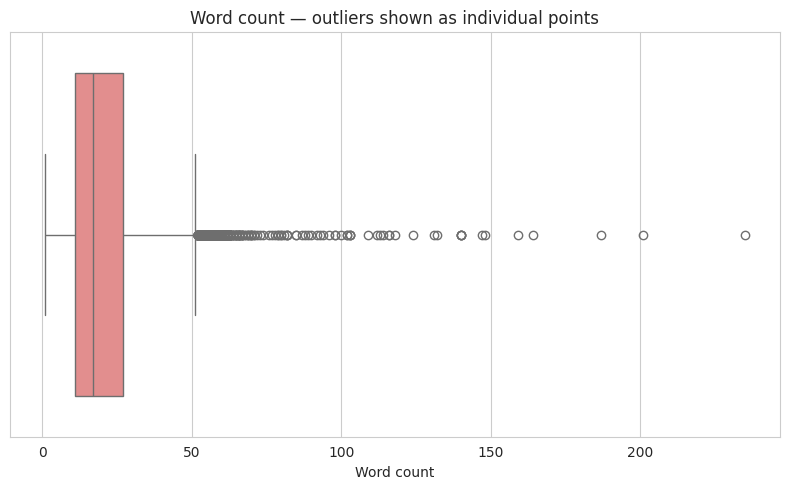

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x=df['word_count'], ax=ax, color='lightcoral')
ax.set_title('Word count — outliers shown as individual points')
ax.set_xlabel('Word count')
plt.tight_layout()
save_figure(fig, 'eda_outlier_analysis.png')
plt.show()

---
## Section 8 — Bivariate Analysis

============================================================ SECTION 8 — BIVARIATE ANALYSIS============================================================


/tmp/ipykernel_8936/197250279.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='word_count', ax=axes[0,0], palette='Set2')
/tmp/ipykernel_8936/197250279.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='emoji_count', ax=axes[0,1], palette='Set2')
/tmp/ipykernel_8936/197250279.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='english_ratio', ax=axes[1,0], palette='Set2')
/tmp/ipykernel_8936/197250279.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is

Saved -> ../outputs/figures/eda_bivariate_comparison.png


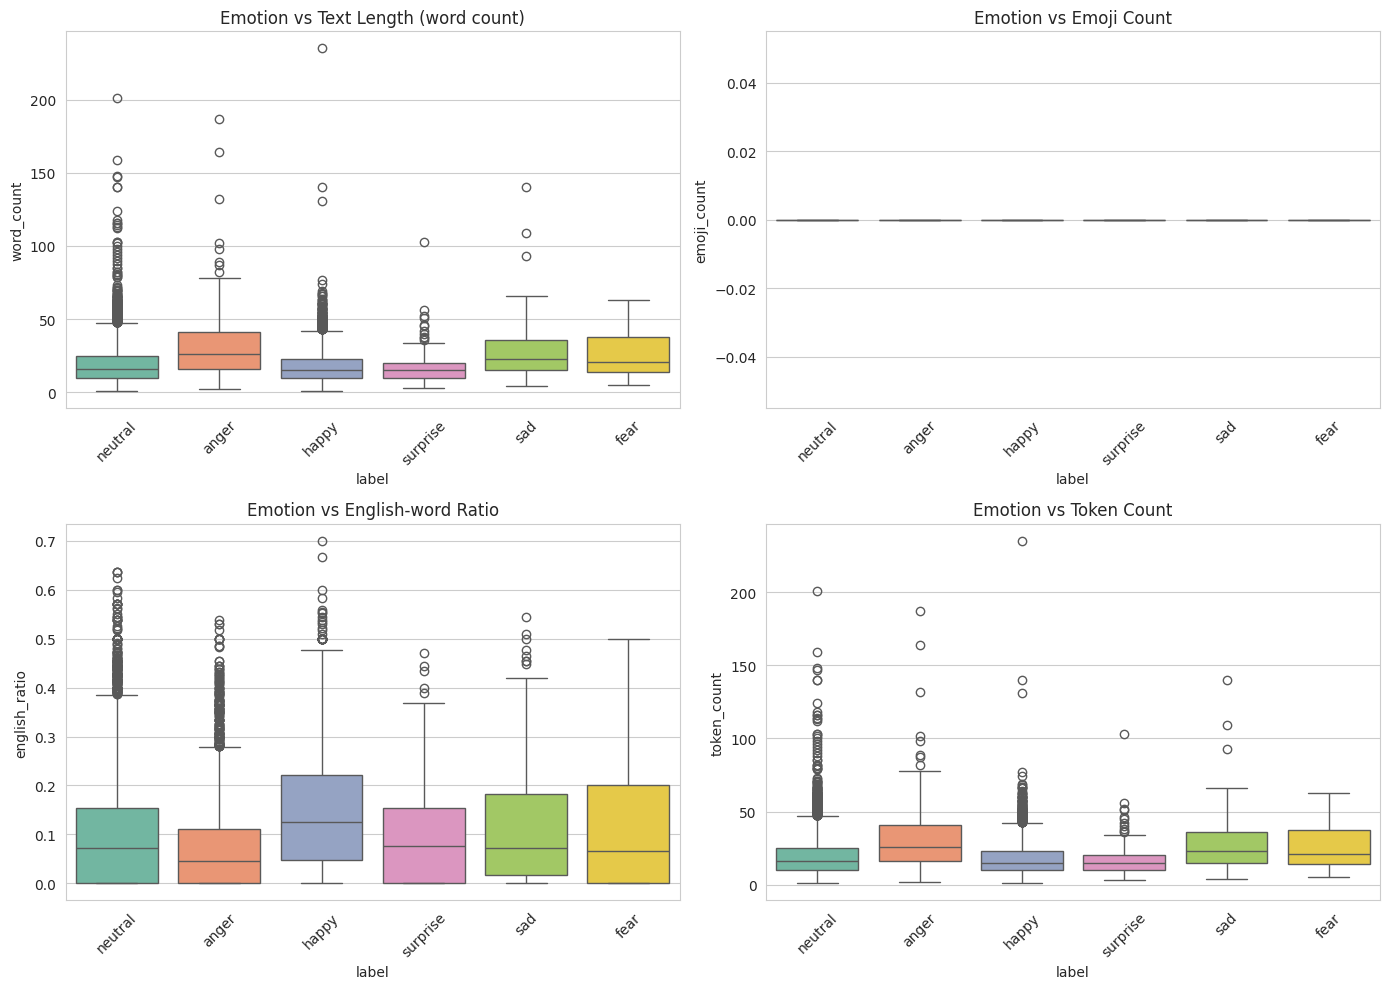

In [20]:
print_section("SECTION 8 — BIVARIATE ANALYSIS")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='label', y='word_count', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Emotion vs Text Length (word count)')
axes[0,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='label', y='emoji_count', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Emotion vs Emoji Count')
axes[0,1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='label', y='english_ratio', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Emotion vs English-word Ratio')
axes[1,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='label', y='token_count', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Emotion vs Token Count')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_figure(fig, 'eda_bivariate_comparison.png')
plt.show()

In [21]:
print("Mean values by emotion:")
print(df.groupby('label')[['word_count', 'emoji_count', 'english_ratio']]
        .mean().round(2))

Mean values by emotion:
          word_count  emoji_count  english_ratio
label                                           
anger          28.84          0.0           0.08
fear           26.19          0.0           0.12
happy          18.14          0.0           0.14
neutral        19.85          0.0           0.10
sad            26.99          0.0           0.11
surprise       17.13          0.0           0.11


---
## Section 9 — Multivariate Analysis

============================================================ SECTION 9 — MULTIVARIATE ANALYSIS============================================================
Saved -> ../outputs/figures/eda_multivariate_correlation.png


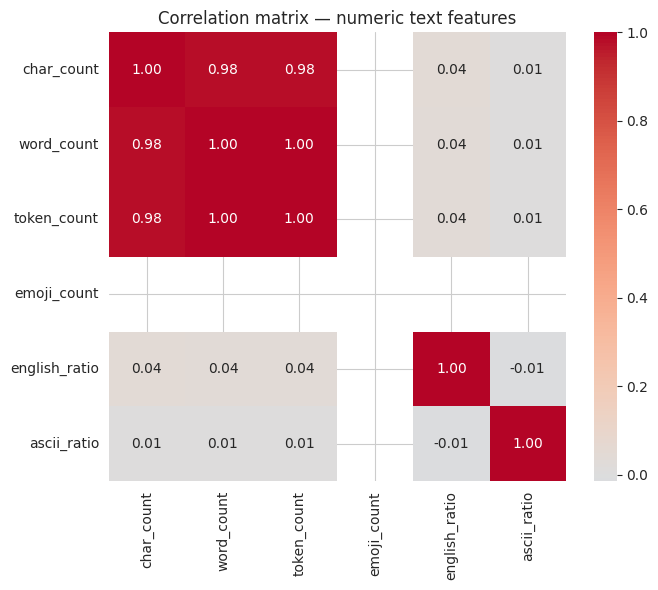

In [22]:
print_section("SECTION 9 — MULTIVARIATE ANALYSIS")

numeric_cols = ['char_count', 'word_count', 'token_count', 'emoji_count',
                 'english_ratio', 'ascii_ratio']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix — numeric text features')
plt.tight_layout()
save_figure(fig, 'eda_multivariate_correlation.png')
plt.show()

Saved -> ../outputs/figures/eda_multivariate_pairplot.png


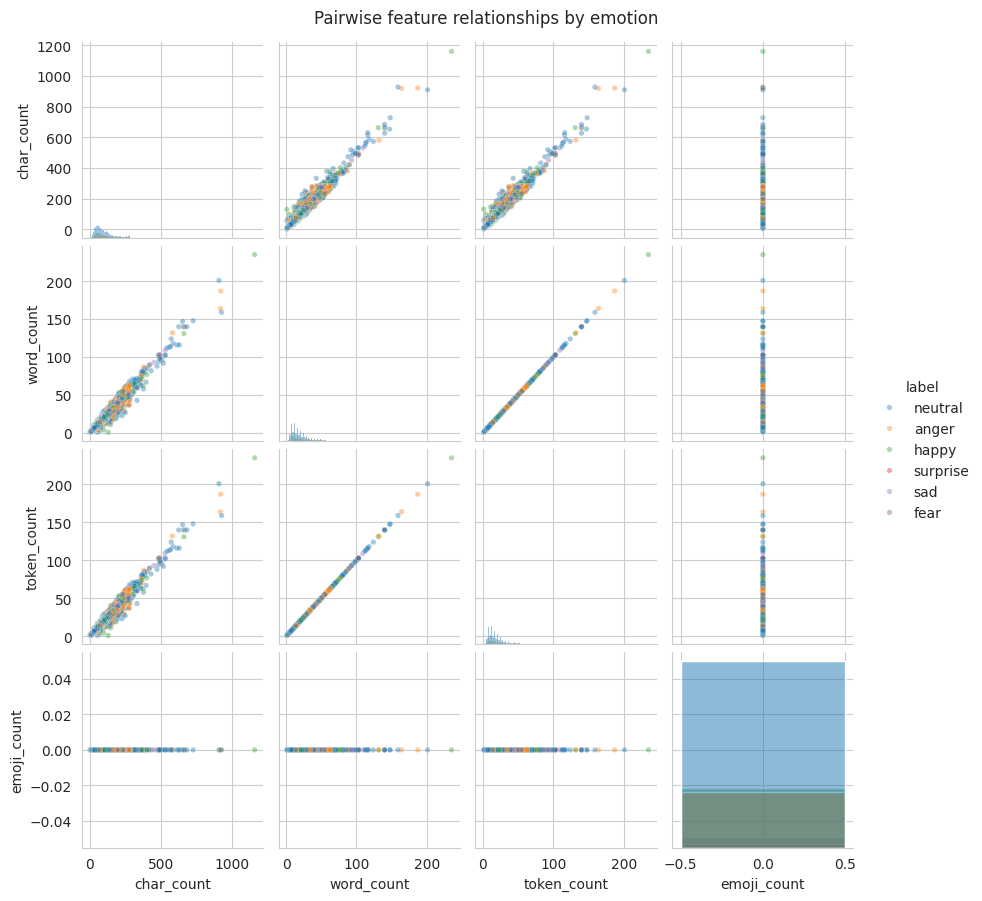

In [23]:
pair_fig = sns.pairplot(
    df[numeric_cols[:4] + ['label']],
    hue='label', diag_kind='hist',
    plot_kws={'alpha': 0.4, 's': 15}, height=2.2
)
pair_fig.fig.suptitle('Pairwise feature relationships by emotion', y=1.02)
pair_fig.savefig(FIGURES_PATH / 'eda_multivariate_pairplot.png',
                  dpi=150, bbox_inches='tight')
print(f"Saved -> {FIGURES_PATH / 'eda_multivariate_pairplot.png'}")
plt.show()

---
## Section 10 — Data Quality Checks

In [24]:
print_section("SECTION 10 — DATA QUALITY CHECKS")

empty_texts     = (df['text_clean'].str.strip() == '').sum()
all_english     = (df['english_ratio'] == 1.0).sum()
excessive_emoji = (df['emoji_count'] > 5).sum()
char_spam       = df['has_char_spam'].sum()
dupes_in_train  = df.duplicated(subset='text_clean').sum()

checks = ['Empty texts', '100% English sentences', 'Excessive emoji (>5)',
          'Repeated-char spam', 'Duplicate text in train']
values = [empty_texts, all_english, excessive_emoji, char_spam, dupes_in_train]

quality_report = pd.DataFrame({
    'check': checks,
    'count': values,
    'pct':   [round(v / len(df) * 100, 2) for v in values],
})
print(quality_report.to_string(index=False))

============================================================ SECTION 10 — DATA QUALITY CHECKS============================================================
                  check  count  pct
            Empty texts      0  0.0
 100% English sentences      0  0.0
   Excessive emoji (>5)      0  0.0
     Repeated-char spam      0  0.0
Duplicate text in train      0  0.0


---
## Section 11 — Key Findings

**Dataset overview**
- Train split: [Run notebook to fill in] rows, 0 missing values, 0 duplicates

**Class distribution**
- Rarest class: surprise (1.1%), imbalance ratio 54.9x
- Confirms NB03's weighted-loss decision is necessary

**Text length**
- Median word count: 17, 95th percentile token count: 51
- max_length=128 in NB03 covers ~[X]% of train sentences

**Language composition**
- Code-mixed: 17.9% (2,450/13,674), mostly Roman Urdu: 82.1% (11,224/13,674)
- 100% English sentences: 0

**Emoji usage**
- 0% of sentences contain at least one emoji
- [emotion] uses the most emojis on average (0 per sentence)
- Emoji presence looks like a strong, cheap signal worth keeping in model input

**Token patterns**
- 12/20 top tokens are stopwords
- Top content words per class: see figure eda_top_tokens_per_emotion.png

**Outliers**
- Shortest sentences: [X] words — mostly [pattern]
- Longest sentences: [X] words — [pattern]
- [X]% show repeated-character emphasis — preserved, not noise

**Data quality**
- [X] empty texts / [X] excessive-emoji rows / [X] char-spam rows
- No blocking issues found

**Feature engineering opportunities for later notebooks**
- `english_ratio` and `emoji_count` are candidate auxiliary features if a classic ML baseline is added alongside XLM-R
- `language_mix` bucket could stratify NB05's bias audit groups directly

**Modeling risks to carry forward**
- [Rarest class] has the fewest training examples — expect it to be the hardest class in NB03's classification report
- Check if any emotion shows notably different length/emoji patterns that could confound predictions

---
## Notebook Summary

| Section | Finding |
|---|---|
| Overview | [X] rows, clean, no missing/duplicate values |
| Target | Imbalance ratio [X]x — rarest class is [X] |
| Length | Median [X] words, p95 token count [X] |
| Language | [X]% code-mixed |
| Emojis | [X]% of sentences contain emojis |
| Tokens | Top tokens dominated by [stopwords / content words] |
| Outliers | [X] flagged as very short/long |
| Quality | No blocking issues found |

**Figures saved:** 10 PNG files in `outputs/figures/` (all with `eda_` prefix)

**Next notebook:** `NB03_finetuning.ipynb`

**Connections to downstream notebooks:**
- Use `english_ratio` as the basis for NB05's code-switch bias audit groups
- Use the rarest class found here to sanity-check NB03's class weights
- Use 95th percentile token count to validate NB03's max_length=128 choice